# API0067 - Projet 2 


<p style="text-align: right;">
Rania ATTOUR et Asma KHOULA
</p>
<p style="text-align: right;">
Intersemestre E24 
</p>


## INTRODUCTION

Dans le cadre de notre formation en ingénierie à l'Université de Technologie de Compiègne, nous avons eu l'opportunité de suivre l'UV RO03 qui traite de la recherche opérationnelle et de l'optimisation combinatoire. Cette UV nous a permis d'avoir une première initiation à l'optimisation. Par la suite nous avons saisi l'occasion de découvrir une nouvelle approche de l'optimisation grâce à cette API.

## SYNTHÈSE DU TRAVAIL RÉALISÉ 

Nous considérons le modèle SIR avec vaccination :
$$
\left\{
\begin{align}
 S'(t) &= -\alpha S(t)I(t) -u(t)S(t), \\
 I'(t) &= \alpha S(t)I(t) −\beta I(t), \\
 R'(t) &= \beta I(t) + u(t)S(t), \\
\end{align}
\right.
$$
sur $ [0,T], $ avec $T = 12$ (mois), 
 $\alpha = 0.0025, $ 
 $\beta = 0.111, $
 $ S(0) = 800 = S_0, $
 $ I(0) = 10 = I_0 $


## 1- Problème direct

Tout d'abord, nous allons simuler et représenter $S,I$ et $R$ en considérant $u(t) = 0$.

#### Simulation de S,I et R

##### Donnnées du problème

Nous commençons par initialiser les données du problème.

Nous avons : <br>

$S(t) $ représente le nombre de personnes susceptibles d'être infectées,<br>
$I(t) $ représente le nombre de personnes infectées,<br>
$R(t) $ représente le nombre de personnes rétablies, immunisées ou mortes,<br>
$\alpha $ est le taux de transmission de la maladie,<br>
$\beta $ est le taux de guérison.

 Enfin, on initialise le nombre de pas de temps $N$ à 100. 

In [ ]:
T = 12;
alpha = 0.0025;
beta = 0.111;
S0 = 800;
I0 = 10;
R0 = 0;
N = 100;

Pour préparer notre simulation, nous générons N points uniformément espacés entre 0 et $T$ avec la fonction $linspace()$.

In [ ]:
t = linspace(0, T, N);

##### Fonction sir

Une fois les données correctement initialisées, nous pouvons passer à la simulation. Nous commençons par définir la fonction $sir()$. Celle-ci définit le modèle SIR (Sensibles, Infectés, Récupérés) à l'aide d'équations différentielles. Pour cela, nous définissons les équations différentielles pour $S(t)$, $I(t)$, et pour $R(t)$. La fonction renvoit un vecteur colonne des dérivées.

In [ ]:
function dydt = sir(t, y)
    S = y(1);
    I = y(2);
    R = y(3);
    dSdt = -alpha * S * I;
    dIdt = alpha * S * I - beta * I;
    dRdt = beta * I;
    dydt = [dSdt; dIdt; dRdt];
endfunction

##### Résolution du système d'équation

Afin de faire notre simulation, nous initialisons le vecteur colonne $Y_0$, qui contient les données à l'instant $t=0$ c'est-à-dire $S_0$, $I_0$ ainsi que $R_0$.

In [ ]:
y0 = [S0; I0; R0];

Nous résolvons maintenant le système d'équations différentielles avec les conditions initiales c'est-à-dire le vecteur $Y_0$ mis en paramètre. Pour cela, nous utilisons un solveur d'équations différentielles, le solveur $ode()$, pour résoudre le système défini par la fonction $sir()$ sur l'intervalle de temps $t$.

In [ ]:
y = ode(y0, 0, t, sir);

#### Représentation graphique

Maintenant que le système d'équations différentielles a été résolue avec le solveur, nous pouvons représenter $S(t)$, $I(t)$ et $R(t)$. Nous utilisons l'instruction $plot()$ pour tracer les courbes de $S(t)$, $I(t)$ et $R(t)$ qui correspondent respectivement à la permière, deuxième et troisième ligne du vecteur $y$.

In [ ]:
clf;
plot(t, y(1, :));
plot(t, y(2, :), 'r');
plot(t, y(3, :), 'm');
legend('S(t)', 'I(t)', 'R(t)');

## 2- Optimisation d’un taux de vaccination constant dans le temps

Désormais nous considérons $u$  constant. Nous cherchons donc à déterminer $u$ en minimisant la fonctionnelle
$$
 J(u) = I(t) + cTu^2,
$$
avec la contrainte $u ≤ 0.9$.

<p>
    Pour cela, nous allons utiliser la méthode des sensibilités et le solveur cvode()
</p>

#### Recherche du taux optimal

##### Ajout de variable

Bien que nous réutilisons les mêmes variables que pour la première partie, la partie d'optimisation du taux de vaccination nécessite la déclaration de nouvelles variables : <br>$c$ le coût de la vaccination ainsi que $h$ la taille d'un pas.

In [ ]:
c = 1; 
h = T / N;

Également, nous initialisons le taux de vaccination, supposé constant au cours du temps.

In [ ]:
u = 0.5;

##### Fonction sir avec vaccination à taux constant 

Cette fois-ci, nous déclarons la fonction $sir$_ $vaccination$_ $const()$, qui représente le modèle $SIR$ en tenant compte du taux de vaccination. Nous reprenons donc le modèle de la fonction $sir$ de la première partie en y ajoutant les termes qui sont désormais non nuls.  

In [ ]:
function dydt=sir_vaccination_const(t, y, u)
    S = y(1);
    I = y(2);
    R = y(3);
    dSdt = -alpha * S * I - u * S;
    dIdt = alpha * S * I - beta * I;
    dRdt = beta * I + u * S;
    dydt = [dSdt; dIdt; dRdt];
endfunction

Ensuite, nous déclarons la fonction de cout qui calcule la jacobienne et sa dérivée par rapport à u.<br>
Pour le calcul de J, nous reprenons la formule ci-dessus en notant que $I(T)$ représente le nombre de personnes infectées à l'instant final $T$. Il s'agit donc de $y(2, \$)$ qui représente bien la dernière des valeurs de $I$ contenues dans $y(2, :)$. <br>
Pour calculer DJ, il suffit de dériver la fonctionnelle $J$ par rapport à $u$. Nous obtenons :<br>
 $$DJ(u) = 2cTu+dudI(T)$$
<br>
Le terme $$dudI(T)$$ représente la sensibilité de $I$ par rapport à $u$ et mesure la façon dont le nombre d'infectés $I$ à la fin de la période $T$ change par rapport au taux de vaccination $u$. Nous avons donc extrait les sensibilités, et notamment $dIdu$ nécessaire pour calculer DJ, en utilisant les informations fournies par le solveur $cvode()$.

In [ ]:
function [J, DJ]=cost_const(u, flag)
    
    [t, y, info] = cvode(sir_vaccination_const, t, y0, sensPar = u);
    
    dS_du = info.s(1, :, :); 
    dI_du = info.s(2, :, :);
    dR_du = info.s(3, :, :); 
    
    J = c * T * u^2 + y(2, $); 
        
    DJ = 2 * u * c * T + dI_du($);
    
endfunction

Enfin, l'optimisation est réalisée en utilisant la fonction $ipopt$ pour trouver le taux de vaccination $u$ qui minimise le coût. Nous choisissons comme limite supérieure pour $u$ 0.9 c'est-à-dire que le taux de vaccination ne peut pas dépasser 90%. Finalement, nous effectuons la résolution du problème d'optimisation avec  $ipopt()$.

In [ ]:
problem = struct();
problem.f = cost_const;
problem.x0 = u;
problem.x_upper = 0.9;
uopt = ipopt(problem);

#### Représentation graphique

Nous traçons le taux de vacination optimal, et on obtient une droite, ce qui est cohérent puisque $u$ est constant.

In [ ]:
clf;
uopt = ipopt(problem);
plot(t, uopt);

## 3- Optimisation de la vaccination pour tout t

Notre objectif est maintenant de déterminer u(t) sur $[0,T]$ afin que la fonctionnelle 
$$ J(u) = I(T) +c\int_{0}^{T} u(t)^2 dt $$
soit minimale avec la contrainte $u(t) ≤ 0.9$. Nous utiliserons pour cela l'approche discrète.

##### Redéfinition des données

Pour commencer, nous définissons le vecteur colonne $Y_0$, cette fois-ci composé seulement de $S_0$ et $I_0$ car $R_0$ ne sera pas utilisé lors de cette partie. 

In [ ]:
y0 = [S0; I0];

La variable $u$ de la deuxième partie est écrasée, c'est désormais un vecteur que nous initialisons avec la valeur $0.5$

In [ ]:
u = ones(1,N) * 0.5;

Également, nous définissons la fonction $sir$_ $vaccination()$ qui est similaire à la fonction $sir$_ $vaccination$_ $const()$ sans la partie relative à $R$.

In [ ]:
function dydt=sir_vaccination(t, y, u)
    S = y(1);
    I = y(2);
    dSdt = -alpha * S * I - u * S;
    dIdt = alpha * S * I - beta * I;
    dydt = [dSdt; dIdt];
endfunction

Dans cette troisième partie, nous déclarons une nouvelle fonction de coût pour un $u(t)$ non constant cette fois. Pour la définir, nous nous sommes grandement inspirées de la fonction coût définie lors du TD3 (cf fichier ressort.sce). Celle-ci utilise l'approche discrète du contrôle optimal.<br><br>
Afin de résoudre ce problème de contrôle optimal, nous utilisons l'approche Lagrangienne. Pour se faire, nous discrétisons l'équation d'état à l'aide du schéma d'Euler, qui donne notamment la relation de récurrence entre $X_k$ et $X_{k+1}$, et nous approchons les intégrales avec la méthode des rectangles à gauche. Nous remplaçons l'équation d'état continue par une discrète en utilisant la formule du cours :<br>$$X_{k+1} = X_k + hf(t_k, X_k, u_k)$$
<br><br>
Ces formules sont donc utilisées dans la première boucle $for$ afin de calculer $X$ et la partie $ c\int_{0}^{T} u(t)^2 dt $ de  $J(u)$.<br>
Nous extrayons ensuite $S$ et $I$ utiles pour les calculs de $J$ la fonctionnelle et de sa dérivée.<br>
En effet, d'après l'énoncé, pour obtenir $J(u)$ à n'importe quel instant $t$, il suffit d'ajouter $I(T)$ au $J$ calculé précédemment.
<br><br>
Nous allons désormais déterminer l'état adjoint $\lambda$. D'après les formules du cours : <br><br> 

$$\lambda_{i-1} = \lambda_i + h( \frac{\partial f}{\partial X} (t_i, x_i, u_i)^\intercal \lambda_i - \frac{\partial \phi}{\partial X} (x_i, u_i))$$ et  $\lambda_{N-1} = - \frac{\partial \phi}{\partial X} (x_N)^\intercal $<br>
Donc $ \lambda_{N-1} = ( - \frac{\partial \phi}{\partial X} (X) )^\intercal$

Pour déterminer les $\lambda_i$, nous devons calculer dans une nouvelles boucle $for$ les $A(i)$ qui correspondent à la dérivée de $f$ par rapport à X  $\frac{\partial f}{\partial X}$ à l'instant $i$. Nous avons $ f = \binom{- \theta_1 X_2 X_1 - uX_1}{\theta_1 X_1 X_2 - \theta_2 X_2} $ <br>En dérivant, nous obtenons $\frac{\partial f}{\partial X} = 
\begin{pmatrix}
-\theta_1 X_2 - u & \theta_1 X_2 \\
-\theta_1 X_1 & \theta_1 X_1 - \theta_2
\end{pmatrix}
$
<br><br>
Enfin, il nous reste à calculer la dérivée de la fonctionnelle. D'après le cours nous avons : 
$$
\begin{align}
\frac{\partial J}{\partial u_i} (u) &= \frac{\partial L}{\partial u_i} (X, u,\lambda) \\
\frac{\partial J}{\partial u_i} (u) &= h \frac{\partial \phi}{\partial u}(x_i, u_i) + \lambda_i^\intercal h \frac{\partial f}{\partial u} (t_i, x_i, u_i)
\end{align}
$$  <br>
avec dans notre problème : $\frac{\partial \phi}{\partial u} = 2cu(t) $ et $\frac{\partial f}{\partial u} = \binom{-S(t)}{0}$<br> Finalement, nous obtenons : $$\frac{\partial J}{\partial u_i} (u) = 2hcu(t) + \lambda_i^\intercal h \binom{-S(t)}{0}  $$

In [1]:
function [J, DJ, X]=cost(u, flag)
    X = zeros(2, N+1);
    X(:,1) = y0;
    J = 0
    for i = 1:N
        X(:, i+1) = X(:, i) + h * sir_vaccination(t(i), X(:, i), u(i));
        J = J + c * h * u(i)^2;
    end
    S = X(1, :);
    I = X(2, :);
    J = J + I($); 
    lambda = zeros(2, N);
    lambda(:, N-1) = [0; -1];
    for i = N-1:-1:2
        Ai = [-alpha * I(i) - u(i),  -alpha * S(i); alpha * I(i), alpha * S(i) - beta];
        lambda(:, i-1) = lambda(:, i) + h * (Ai' * lambda(:, i));
    end
    DJ = zeros(1, N);
    for i = 1:N
        DJ(i) = 2 * h * c * u(i) - lambda(:, i)' * h * [-S(i); 0];
    end 
endfunction


Attention : redéfinition de la fonction cost                    . Utiliser funcprot(0) pour éviter ce message

Nous trouvons la solution optimale en utilisant l'algorithme $ipopt()$, pour résoudre ce problème d'optimisation en respectant les contraintes imposées sur 
$u$.

In [2]:
problem = struct();
problem.f = cost;
problem.x0 = u;
problem.x_upper=ones(N, 1)*0.9;
problem.tol = 1e-4;
uopt = ipopt(problem);

Variable non définie : ipopt

#### Représentation graphique

On trace enfin le taux de vacination optimal. 

Variable non définie : ipopt

Variable non définie : uopt


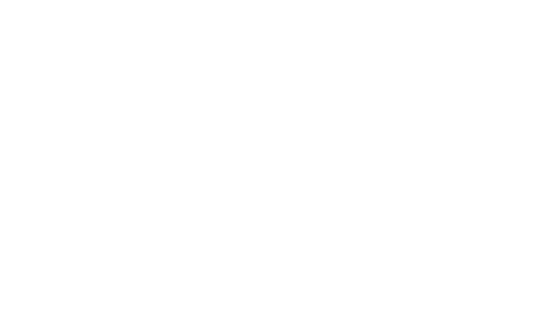

In [3]:
clf;
uopt = ipopt(problem);
plot(t, uopt);

# CONCLUSION

En conclusion, cette API nous permis de renforcer nos compétences en optimisation et analyse numérique, tout en nous familiarisant avec l'outil Scilab pour des applications pratiques. Le mini-projet nous a permis d'aborder une situation  concrète, et même si nous n'avions qu'une partie des prérequis, nous nous sommes réellement challengeés afin de comprendre les méthodes employées dans le cours et de les pouvoir les appliquer. Nous sommes convaincues que cet apprentissage nous sera bénéfique dans notre future carrière d'ingénieure.<br><br>
Nous tenions à vous remercier pour cette semaine et toutes les connaissances partagées. 